# CHƯƠNG 4 — THỰC NGHIỆM SIMPLE RNN VÀ GRU

**Bài toán:** từ **24 giờ nhiệt độ trước đó**, dự đoán nhiệt độ của **1 giờ kế tiếp**; so sánh SimpleRNN, GRU và baseline **lấy nhiệt độ giờ trước**.

> **CHÚ Ý QUAN TRỌNG:** nhiệt độ ở đây là **chuỗi dữ liệu được tạo bằng công thức mô phỏng**, không phải dữ liệu lấy từ cảm biến ESP8266/DHT11 thực tế. Khi báo cáo phải ghi rõ là *synthetic data*.

**Dữ liệu:** mô phỏng 45 ngày × 24 giờ = 1.080 điểm. Notebook độc lập, **không cần file CSV**.

## Bước 1. Import thư viện và cài seed

In [1]:
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)
OUT = Path('ket_qua')
OUT.mkdir(exist_ok=True)
print('Đường dẫn kết quả:', OUT.resolve())

Đường dẫn kết quả: D:\tlHTTM\Bo_code_Jupyter_Tieu_luan_01\ket_qua


## Bước 2. Tạo chuỗi nhiệt độ mô phỏng

Chuỗi gồm nhiệt độ nền 25°C, dao động ngày đêm (chu kỳ 24 giờ), dao động tuần, biến thiên chậm và nhiễu ngẫu nhiên. Công thức được mô phỏng theo ví dụ để học thuật toán, **không phản ánh đo đạc thật**.

In [2]:
rng = np.random.default_rng(SEED)
t = np.arange(24 * 45)  # 45 ngày, mỗi giờ một mốc
# Dao động ngày đêm + dao động tuần + xu hướng + nhiễu
series = (
    25
    + 2.8 * np.sin(2 * np.pi * t / 24 - 0.5)
    + 0.9 * np.sin(2 * np.pi * t / (24 * 7))
    + 0.001 * t
    + rng.normal(0, 0.25, size=len(t))
)
print('Số quan sát:', len(series))
print('Nhiệt độ nhỏ nhất/lớn nhất:', round(series.min(),2), round(series.max(),2))

Số quan sát: 1080
Nhiệt độ nhỏ nhất/lớn nhất: 21.37 29.86


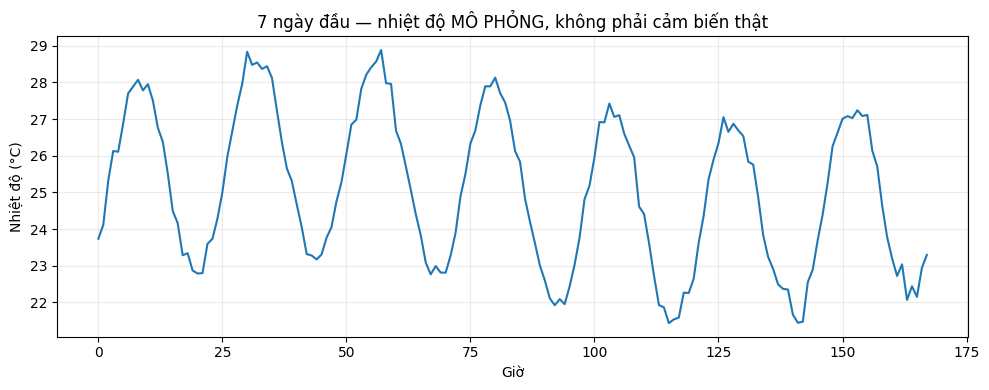

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t[:168], series[:168])
ax.set_xlabel('Giờ'); ax.set_ylabel('Nhiệt độ (°C)')
ax.set_title('7 ngày đầu — nhiệt độ MÔ PHỎNG, không phải cảm biến thật')
ax.grid(alpha=.25)
fig.tight_layout()
plt.show()
fig.savefig(OUT / 'chuong4_nhiet_do_mo_phong.png', dpi=160)
plt.close(fig)

## Bước 3. Chia chuỗi theo thứ tự thời gian

**Không dùng `train_test_split(shuffle=True)` cho chuỗi thời gian:** dữ liệu tương lai không được xuất hiện khi huấn luyện quá khứ.

Khoảng 70% đầu dành cho train; 15% tiếp theo validation; 15% cuối test. `mu, sd` tính chỉ trên **đoạn train** để chuẩn hóa, tránh rò rỉ dữ liệu.

In [4]:
lookback = 24
cutoff_train = int(0.70 * len(series))
cutoff_valid = int(0.85 * len(series))
mu = float(series[:cutoff_train].mean())
sd = float(series[:cutoff_train].std())
scaled = (series - mu) / sd
print('Train trước mốc:', cutoff_train, '| Validation trước mốc:', cutoff_valid)
print('Mean/std tập train:', round(mu,3), round(sd,3))

Train trước mốc: 756 | Validation trước mốc: 918
Mean/std tập train: 25.454 2.106


## Bước 4. Tạo các cửa sổ 24 giờ

Mỗi mẫu có `X = [nhiệt độ 24 giờ trước]`, `Y = [nhiệt độ giờ kế tiếp]`.

`seqX.shape = (1056, 24, 1)` tương ứng `[số mẫu, số bước thời gian, số đặc trưng]`. Để đánh giá đúng thứ tự, ta tách tập theo **chỉ số thời điểm dự đoán**.

In [5]:
seqX, seqY, target_indices = [], [], []
for i in range(lookback, len(series)):
    seqX.append(scaled[i-lookback:i])
    seqY.append(scaled[i])
    target_indices.append(i)
seqX = np.array(seqX, dtype=np.float32)[:, :, None]
seqY = np.array(seqY, dtype=np.float32)[:, None]
target_indices = np.array(target_indices)

train_mask = target_indices < cutoff_train
valid_mask = (target_indices >= cutoff_train) & (target_indices < cutoff_valid)
test_mask = target_indices >= cutoff_valid
print('seqX:', seqX.shape, 'seqY:', seqY.shape)
print('Mẫu train:', train_mask.sum(), 'valid:', valid_mask.sum(), 'test:', test_mask.sum())
print('Ví dụ X của mẫu đầu:', seqX[0, :5, 0], '...')
print('Nhãn cần dự đoán Y đầu:', seqY[0, 0])

seqX: (1056, 24, 1) seqY: (1056, 1)
Mẫu train: 732 valid: 162 test: 162
Ví dụ X của mẫu đầu: [-0.81678396 -0.63626504 -0.06224626  0.31962976  0.31012806] ...
Nhãn cần dự đoán Y đầu: -0.5583062


## Bước 5. Khai báo SimpleRNN và GRU

`nn.RNN(1,16)` / `nn.GRU(1,16)` nhận 1 đặc trưng mỗi giờ và duy trì trạng thái ẩn gồm 16 phần tử; `out[:, -1, :]` lấy đầu ra cuối cùng của chuỗi 24 giờ; Dense 16→1 dự đoán nhiệt độ chuẩn hóa.

In [6]:
class SeqRegressor(nn.Module):
    def __init__(self, kind):
        super().__init__()
        if kind == 'SimpleRNN':
            self.rec = nn.RNN(input_size=1, hidden_size=16, batch_first=True)
        elif kind == 'GRU':
            self.rec = nn.GRU(input_size=1, hidden_size=16, batch_first=True)
        else:
            raise ValueError('kind phải là SimpleRNN hoặc GRU')
        self.fc = nn.Linear(16, 1)

    def forward(self, x):
        outputs, hidden = self.rec(x)
        last_output = outputs[:, -1, :]
        return self.fc(last_output)

print('Tham số SimpleRNN:', sum(p.numel() for p in SeqRegressor('SimpleRNN').parameters()))
print('Tham số GRU:', sum(p.numel() for p in SeqRegressor('GRU').parameters()))

Tham số SimpleRNN: 321
Tham số GRU: 929


## Bước 6. Huấn luyện từng mô hình

`MSELoss`: bình phương sai lệch giữa dự đoán và thực tế. `clip_grad_norm_` giúp ngăn **bùng nổ gradient**. Sau 25 epoch, chọn trọng số có **validation MSE nhỏ nhất**.

Mỗi mô hình khởi tạo lại seed để so sánh nhất quán; cả hai dùng cùng đoạn dữ liệu và tiêu chí.

In [7]:
def fit_sequence_model(kind, num_epochs=25):
    torch.manual_seed(SEED)
    model = SeqRegressor(kind)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    loss_fn = nn.MSELoss()
    Xtr = torch.from_numpy(seqX[train_mask]); ytr = torch.from_numpy(seqY[train_mask])
    Xva = torch.from_numpy(seqX[valid_mask]); yva = torch.from_numpy(seqY[valid_mask])
    loader = DataLoader(
        TensorDataset(Xtr, ytr), batch_size=32, shuffle=True,
        generator=torch.Generator().manual_seed(SEED)
    )
    best_val = float('inf')
    best_epoch, best_state = 0, None
    history = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_total = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_total += loss.item() * len(xb)

        model.eval()
        with torch.no_grad():
            valid_loss = float(loss_fn(model(Xva), yva).item())
        train_loss = train_total / len(Xtr)
        history.append({'Epoch':epoch, 'Train MSE':train_loss, 'Validation MSE':valid_loss})
        if valid_loss < best_val:
            best_val = valid_loss
            best_epoch = epoch
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        if epoch == 1 or epoch % 5 == 0:
            print(f'  Epoch {epoch:02d}: train={train_loss:.4f}, validation={valid_loss:.4f}')

    model.load_state_dict(best_state)
    model.eval()
    return model, pd.DataFrame(history), best_epoch, best_val

In [8]:
trained = {}
history_dict = {}
best_info = {}

for kind in ['SimpleRNN', 'GRU']:
    print('\nĐang huấn luyện:', kind)
    model, hist, best_epoch, best_val = fit_sequence_model(kind)
    trained[kind] = model
    history_dict[kind] = hist
    best_info[kind] = {'epoch': best_epoch, 'validation_mse_scaled': best_val}
    print('=> Epoch được chọn:', best_epoch, '| MSE validation:', round(best_val,5))


Đang huấn luyện: SimpleRNN
  Epoch 01: train=0.3379, validation=0.0728
  Epoch 05: train=0.0322, validation=0.0308
  Epoch 10: train=0.0284, validation=0.0292
  Epoch 15: train=0.0262, validation=0.0279
  Epoch 20: train=0.0287, validation=0.0257
  Epoch 25: train=0.0287, validation=0.0260
=> Epoch được chọn: 16 | MSE validation: 0.02399

Đang huấn luyện: GRU
  Epoch 01: train=0.6744, validation=0.3323
  Epoch 05: train=0.0305, validation=0.0284
  Epoch 10: train=0.0277, validation=0.0305
  Epoch 15: train=0.0263, validation=0.0259
  Epoch 20: train=0.0253, validation=0.0242
  Epoch 25: train=0.0226, validation=0.0241
=> Epoch được chọn: 24 | MSE validation: 0.0221


## Bước 7. Dự đoán tập Test và hoàn nguyên về °C

Vì đã chuẩn hóa bằng `(x-mu)/sd`, cần nhân lại `sd` và cộng `mu` để tính sai số bằng **°C**. Baseline dùng giá trị tại giờ ngay trước đó, không qua mạng nơ-ron.

Lưu ý: đây là **dự báo một bước** dựa trên 24 quan sát thực trước đó, không phải dự báo tự lặp 24 giờ tương lai.

In [9]:
truth = series[target_indices[test_mask]]
last_value_baseline = series[target_indices[test_mask] - 1]
results = []
predictions = {}
for kind, model in trained.items():
    with torch.no_grad():
        pred_scaled = model(torch.from_numpy(seqX[test_mask])).numpy().reshape(-1)
    pred_temp = pred_scaled * sd + mu
    predictions[kind] = pred_temp
    results.append({
        'Mô hình': kind,
        'Test MAE (°C)': mean_absolute_error(truth, pred_temp),
        'Test RMSE (°C)': np.sqrt(mean_squared_error(truth, pred_temp)),
        'Best epoch': best_info[kind]['epoch'],
        'Số tham số': sum(p.numel() for p in model.parameters()),
    })
results.append({
    'Mô hình': 'Persistence baseline',
    'Test MAE (°C)': mean_absolute_error(truth, last_value_baseline),
    'Test RMSE (°C)': np.sqrt(mean_squared_error(truth, last_value_baseline)),
    'Best epoch': None, 'Số tham số': 0,
})
summary = pd.DataFrame(results)
display(summary.round(4))

,Mô hình,Test MAE (°C),Test RMSE (°C),Best epoch,Số tham số
0,SimpleRNN,0.2780,0.3532,16.0,321
1,GRU,0.2601,0.3227,24.0,929
2,Persistence baseline,0.5209,0.6126,NaN,0


## Bước 8. Vẽ đồ thị dự báo và quá trình huấn luyện

Đường gần dữ liệu thực hơn thì dự báo tốt hơn. Biểu đồ được vẽ trên **96 giờ đầu tiên thuộc đoạn test**.

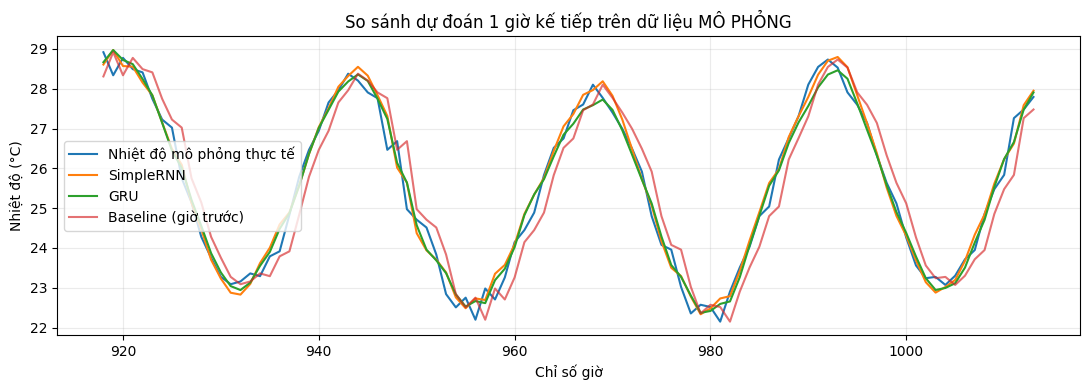

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
N = 96
hours = target_indices[test_mask][:N]
ax.plot(hours, truth[:N], label='Nhiệt độ mô phỏng thực tế')
ax.plot(hours, predictions['SimpleRNN'][:N], label='SimpleRNN')
ax.plot(hours, predictions['GRU'][:N], label='GRU')
ax.plot(hours, last_value_baseline[:N], label='Baseline (giờ trước)', alpha=0.65)
ax.set_xlabel('Chỉ số giờ'); ax.set_ylabel('Nhiệt độ (°C)')
ax.set_title('So sánh dự đoán 1 giờ kế tiếp trên dữ liệu MÔ PHỎNG')
ax.legend(); ax.grid(alpha=.25)
fig.tight_layout()
plt.show()
fig.savefig(OUT / 'chuong4_rnn_du_bao.png', dpi=160)
plt.close(fig)

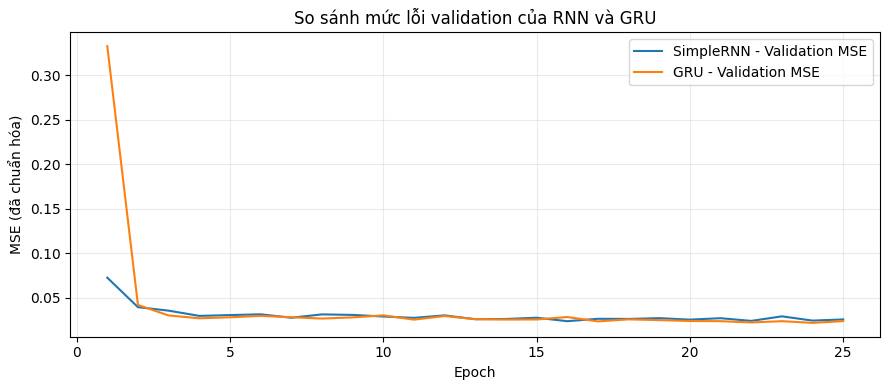

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
for kind, hist in history_dict.items():
    ax.plot(hist['Epoch'], hist['Validation MSE'], label=f'{kind} - Validation MSE')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (đã chuẩn hóa)')
ax.set_title('So sánh mức lỗi validation của RNN và GRU')
ax.legend(); ax.grid(alpha=.25)
fig.tight_layout()
plt.show()
fig.savefig(OUT / 'chuong4_rnn_validation.png', dpi=160)
plt.close(fig)

## Bước 9. Lưu kết quả, lịch sử học và mô hình

In [12]:
summary.to_csv(OUT / 'chuong4_rnn_ket_qua.csv', index=False, encoding='utf-8-sig')
for kind, hist in history_dict.items():
    hist.to_csv(OUT / f'chuong4_{kind}_lich_su.csv', index=False, encoding='utf-8-sig')
    torch.save(trained[kind].state_dict(), OUT / f'chuong4_{kind}_trong_so.pt')

rnn_result = {
    'seed': SEED,
    'dataset': 'SYNTHETIC hourly temperature, NOT real sensor data',
    'hours': len(series),
    'lookback': lookback,
    'targets': {'train':int(train_mask.sum()), 'validation':int(valid_mask.sum()), 'test':int(test_mask.sum())},
    'models': {
        row['Mô hình']: {
            'test_mae_C': float(row['Test MAE (°C)']),
            'test_rmse_C': float(row['Test RMSE (°C)']),
            'best_epoch': None if pd.isna(row['Best epoch']) else int(row['Best epoch']),
            'params': int(row['Số tham số']),
        } for row in results
    },
}
with (OUT/'chuong4_rnn_ket_qua.json').open('w', encoding='utf-8') as f:
    json.dump(rnn_result, f, ensure_ascii=False, indent=2)
print('Đã lưu kết quả trong:', OUT.resolve())

Đã lưu kết quả trong: D:\tlHTTM\Bo_code_Jupyter_Tieu_luan_01\ket_qua


## Ghi nhớ khi thuyết trình

**SimpleRNN** truyền trạng thái ẩn từ bước trước sang bước sau; **GRU** có các cổng điều khiển lượng thông tin giữ lại và cập nhật. **Gradient clipping** hạn chế đạo hàm quá lớn. **Train/validation/test theo thời gian** để không lấy dữ liệu tương lai dự đoán quá khứ. **MAE/RMSE đơn vị °C** càng nhỏ càng tốt.

Nếu thầy yêu cầu **dữ liệu từ cảm biến thật**, notebook này **chưa đáp ứng**; cần thay khối sinh chuỗi mô phỏng bằng đọc và xử lý dữ liệu MQTT lưu thực tế, sau đó chạy lại toàn bộ kết quả.